## 2.1 什么是计算模型？
> *“机器学习(Machine Learning)是研究计算机算法的一门学科，这些算法可以通过经验和数据的使用自动改进。” -- Tom M. Mitchell*
- 机器学习的三大分类
    - 监督学习
    - 无监督学习
    - 强化学习
- 本书主要关注其在心理和认知科学的应用；本书着重探讨监督学习中的神经网络模型以及强化学习中的主要内容。

## 2.2 模型选择
- 模型建立的两个步骤
    - 选择合适的模型
    - 根据数据不断优化模型，增强其对数据的解释力度
        - 我认为后者是十分重要的，关于模型的可解释性。

### 2.2.1 Linear Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
a = 0.5
b = 3
noiseVar = 2
x = np.arange(1,100,1)

# generate data
y = a * x + b + noiseVar * np.random.randn(x.size) # add Gaussian noise while generating data

Text(0.5, 1.0, 'Linear model')

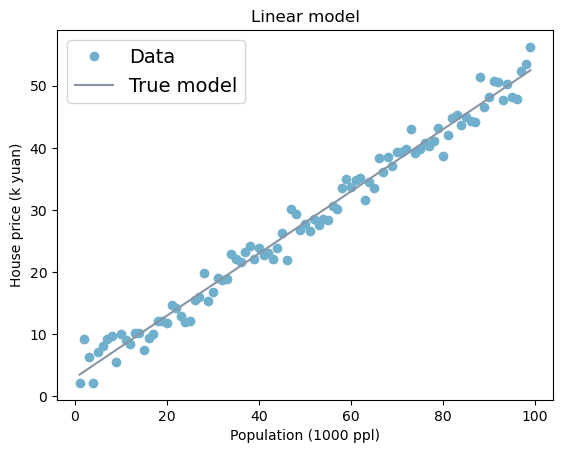

In [5]:
plt.plot(x, y, 'o', color='#70B0CC', label='Data') # plot data
plt.plot(x, a*x+b, '-', color='#8795A5', label='True model') # plot tru model
plt.xlabel('Population (1000 ppl)')
plt.ylabel('House price (k yuan)')
plt.legend(fontsize=14)
plt.title('Linear model')

In [13]:
c = 5
noiseVar_2 = 500
x_2 = np.arange(-50,100,1)
y_2 = a*x_2**2 + b*x_2 +c+ noiseVar_2 * np.random.randn(x_2.size)

Text(0.5, 1.0, 'Linearized model')

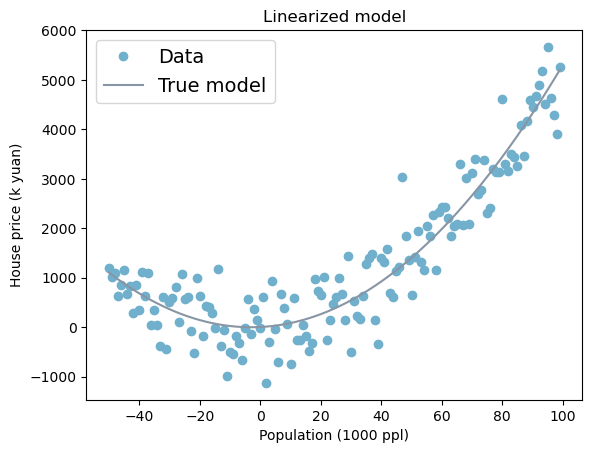

In [15]:
plt.plot(x_2, y_2, 'o', color='#70B0CC', label='Data') # plot data
plt.plot(x_2, a * x_2**2 + b*x_2 + c, '-', color='#8795A5', label='True model') # plot tru model
plt.xlabel('Population (1000 ppl)')
plt.ylabel('House price (k yuan)')
plt.legend(fontsize=14)
plt.title('Linearized model')

### 2.2.2 Nonlinear Model

In [16]:
noiseVar_3 =1
x_3 = np.arange(0.01,3,0.01)
y_3 = np.log(x_3) + noiseVar_3 * np.random.randn(x_3.size)

Text(0.5, 1.0, 'Nonlinear model')

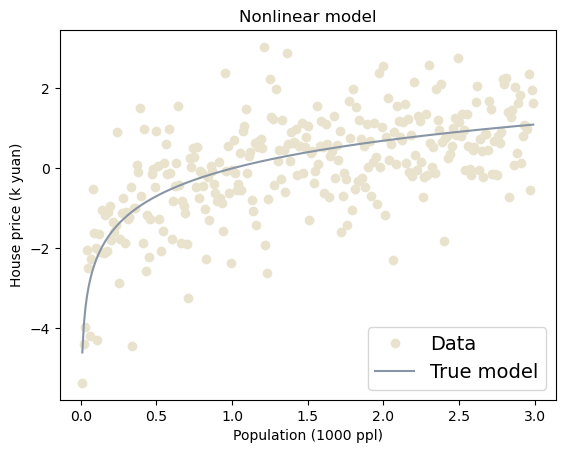

In [17]:
plt.plot(x_3, y_3, 'o', color='#E9E3CE', label='Data') # plot data
plt.plot(x_3, np.log(x_3), '-', color='#8795A5', label='True model') # plot tru model
plt.xlabel('Population (1000 ppl)')
plt.ylabel('House price (k yuan)')
plt.legend(fontsize=14)
plt.title('Nonlinear model')

### 2.2.3 模型之间的差异
- the differences between linear and nonlinear models
    - Nonliear models can't be written as a matrix multiplication.
    - Nonliear models are more complex which need to be optimized.

## 2.3 模型拟合

### 2.3.1 最优化问题
在一定的约束下，找到目标函数的最大值或最小值问题极为最优化问题(Optimization problem)。在计算机中，使用minimize()函数完成。

In [19]:
from scipy.optimize import minimize
 
def func(x): # def loss function
    return (x-1)**2
res = minimize(func, 2) # x0 = 2
print(res.x) # print the solution

[0.99999999]


***Tips**:这个结果非常 **精确但并不完全准确** 。这是因为在计算机的逻辑中，它是通过非常小的步长进行循环然后比较每次函数的大小，最后找出那个最小函数取值时的x值。计算机在这里的工作逻辑有点类似于我们使用枚举法，最后得到一个数值解。*

### 2.3.2 损失函数/成本函数/目标函数
>在最优化问题中，很重要的就是找到最优化的目标是什么，在机器学习领域，一般会用损失函数（Loss Function）、成本函数（Cost Function）或目标函数（Objective Function）来描述即将要优化的对象。
- 损失函数（Loss Function）：反映的是我用我的模型去描述数据时，损失了多少准确信息。即，采用模型得到的预测结果代表真实结果时将造成多少数据损失。
- 成本函数（Cost Function）：指用我的模型去描述真实数据时，想要以这个模型去替代真实数据的 **成本(cost)** 有多高。
- 目标函数（Objective Function）：指模型要最优化的目标。如果目标函数取得最值，则意味着模型有最好表现效果。
*一般来说，损失函数、成本函数、目标函数在机器学习领域都有使用且内涵没有差异，但可能根据具体上下文有些许细微差别，在本书中，认为三者只是同一内容的不同表达，并且在后文中仅使用损失函数来指代这一内容。*
- 因为不同error存在符号差异的问题，一般通过一一系列数学变换使的所有误差均为政治。
- 在求解最优化问题过程中，一般采用岁笑话损失函数的方式实现模型的最好拟合效果。

### 2.3.3 求解线性回归的三种方法
- 手写损失函数求解
- 线性回归的解析解求解
- 算法包直接求解

In [ ]:
# 线性回归的解析解求解
x2 = np.vstack((x, np.ones(x.size))) 
x2 = x2.T # x2 is 99 x 2
y_hat = y[:, np.newaxis].copy() # y is 99 x 1

res = np.linalg.inv(x2.T @ x2) @ x2.T @ y_hat 

print('Coefficient is ',res[0][0])
print('Intercept is ',res[1][0])

Coefficient is  0.49779009327208235
Intercept is  3.0932563943320637


In [ ]:
# 算法包直接求解
x2 = np.vstack((x, np.ones(x.size))) 

# 利用lstsq函数
res = np.linalg.lstsq(x2.T, y, rcond=None)[0]

print('Coefficient is ',res[0])
print('Intercept is ',res[1])

Coefficient is  0.4977900932720818
Intercept is  3.093256394332041


## 2.4 模型准确度
- 模型的准确性（model accuracy）：模型预测的结果和实际数据点两者的差距。
- 当我们需要描述总体数据的特征和关系时，通常的做法是在总体中抽样，根据样本特征（拟合模型）估计总体特征（真模型）。
- 平方误差受到数据点数量的影响，因此一般不用平方误差来衡量模型准确性。

![R^2](./images/Rsquare.png)
![l2p2](./images/l2p2.png)


In [22]:
a = 0.5
b = -2
c = 5
noiseVar = 500
x = np.arange(-50,100,0.1)
y = a * x**2 + b * x + c + noiseVar * np.random.randn(x.size)

def lossfun(params):
    a,b,c = params
    predict_data = a* x**2 + b * x + c
    return((predict_data - y)**2).sum()

res = minimize(lossfun,(0.5,-3,4))
fitParams = res.x

Text(0.5, 1.0, 'Linearized model')

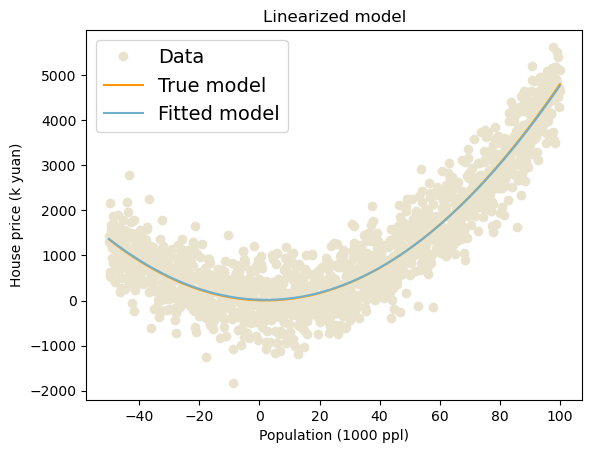

In [25]:
plt.plot(x, y, 'o', color='#E9E3CE', label='Data') # plot data
plt.plot(x, a * x**2 + b*x + c, '-', color='#FF9900', label='True model') # plot tru model
plt.plot(x, fitParams[0]*x**2 + fitParams[1]*x + fitParams[2], '-', color='#70B0CC', label='Fitted model') # plot tru model
plt.xlabel('Population (1000 ppl)')
plt.ylabel('House price (k yuan)')
plt.legend(fontsize=14)
plt.title('Linearized model')

In [26]:
predict_data = fitParams[0]*x**2+fitParams[1]*x + fitParams[2] # mi

R2 = 1-((y-predict_data)**2).sum()/((y-y.mean())**2).sum()
print('R2 is', R2)

R2 is 0.8684265311457454


### Corss-Validation
- 交叉验证（cross-validation）可以体现模型的泛化能力，减少过拟合。
  - 留一交叉验证（leave-one-out cross-validation）
  - k折交叉验证（k-fold cross-validation）
- 具体步骤
  - 在数据集中挑出一些数据，作为测试集；
  - 剩余数据作为训练集，拟合模型；
  - 最后采用测试集的数据评价用训练集拟合出来的模型准确性。
注：测试集和训练集的数据应该是两份独立的数据，不能重合。

In [29]:
# Here We create data
a = 0.5  # coefficient1
b = -2   # coefficient1
c = 5    # intercept
noiseVar = 500 
x = np.arange(-50, 100, 0.1)
# generate data
y =  a * x**2 + b*x + c + noiseVar* np.random.randn(x.size)

idx = np.mod(np.arange(x.size),5)
np.random.shuffle(idx) # let order be random

# corss validation
r2 = np.zeros(5)
for i  in range(5):
    y_train = y[idx !=i].copy()
    y_test = y[idx ==i].copy()
    x_train = x[idx !=i].copy() 
    x_test = x[idx ==i].copy()

# define loss function
lossfun = lambda params: ((params[0]*x_train**2 + params[1]*x_train + params[2] - y_train)**2).sum()
# optimize loss function
res = minimize(fun=lossfun, x0=(0.5, -3, 4)) # 用minimize去优化求解
fitParams = res.x

# calculate R2
y_pred = fitParams[0]*x_test**2+fitParams[1]*x_test+fitParams[2]
r2[i] = 1-((y_test-y_pred)**2).sum()/((y_test-y_test.mean())**2).sum()

print('Cross validation R2 is ', r2)
print('\n The average R2 is', r2.mean())

Cross validation R2 is  [0.         0.         0.         0.         0.88096156]

 The average R2 is 0.17619231135844232


### leave-one-out cross-validation
![](./images/image.png)

- 一般在小样本数据中，常使用留一交叉验证方法。
- 当数据集较大时，K折交叉验证更为通用。K折交叉验证方法将数据随机分为k组，每组分别做一次测试集，剩下的k-1组做训练集。如此循环后，最终会得到k个模型，并有k个模型准确性评价结果。
- 评价一个模型好不好，并非看它在训练集上的表现，而是看它在测试集上的表现。

### 选择合适的模型
过拟合和欠拟合的核心逻辑就是简单模型和复杂模型的平衡问题。根据奥卡姆剃刀原则，在评估解释数据时，应尽量选择简单的模型。而更复杂的模型在拟合能力上似乎总是更强大。尤其在心理学测量中，数据受到噪音的干扰会更明显，一方面我们希望一个足够灵活的模型来描述、解释数据，并做到准确的预测；另一方面，我们需要一个简单的模型，避免有害噪音的影响。
![](./images/l2p4.png)
- High Noise -> simple model
- Low Noise -> complex model

## 2.5 模型可信度

### bootstrap
- 我们希望得到一个尽可能窄的参数估计区间。一般情况下，增加数据集的样本量N能缩小参数估计区间。
- 当样本量很少时（n=10）， 对于参数a和b的估计区间较宽，误差棒也较大，均值也和真实模型有较大的差距；而当样本量较大时（n=200），对于参数a和b的估计区间很窄，误差棒也很小，几乎接近真实模型。
![](./images/l2p5.png)
- 理论上，自举法和交叉验证几乎使用于所有模型，即通过自举法评估模型可靠性，通过交叉验证评估模型准确性。
![](./images/l2p6.png)

### premutation test
- 置换检验应用于知道我们估计出来的参数是否显著。
- 基本流程是构建一个某个参数的零假设的分布，然后利用得到的参数值和该分布做对比。如果得到的参数值在这个分布中处于显著性水平（例如0.05）的两端，则表示该参数值在随机情况下出现的概率较低，从而可以认为该参数值是显著的。